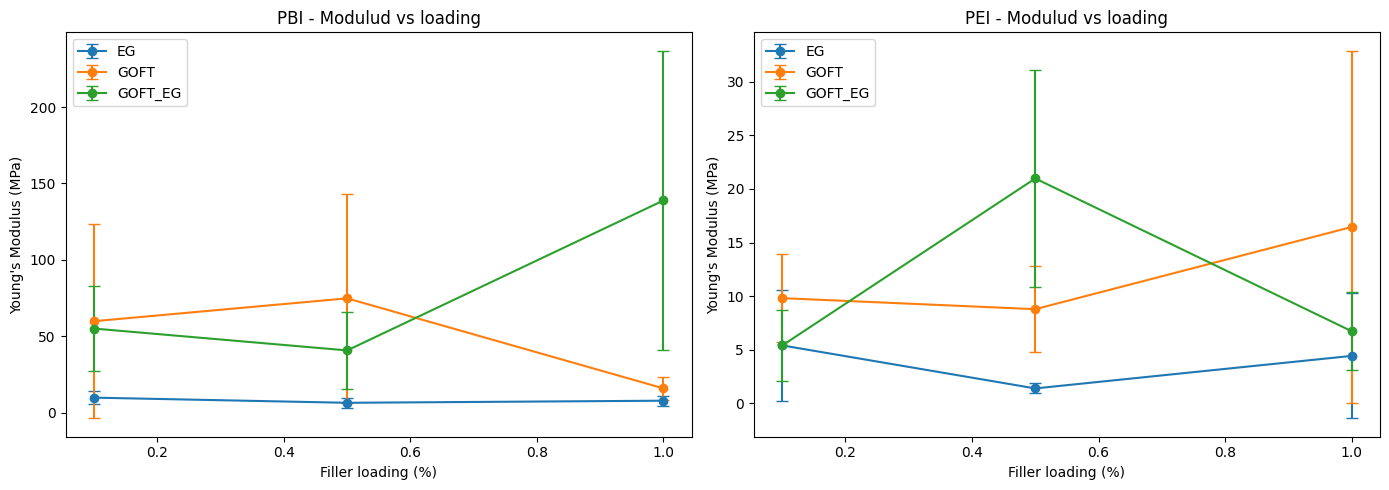

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('polymer_tensile_data.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for filler in  ['EG', 'GOFT', 'GOFT_EG']:
    for polymer, ax in zip(['PBI', 'PEI'], axes):
        subset = df[(df['polymer'] == polymer) &
                    ((df['filler_type'] == filler) | (df['filler_type'] == 'None'))]
        subset = subset.sort_values('loading_pct')
        ax.errorbar(subset['loading_pct'], subset['youngs_modulus_MPa'],
                     yerr=subset['youngs_modulus_sd'],
                     marker='o', label=filler, capsize=4)

for polymer, ax in zip(['PBI', 'PEI'], axes):
    ax.set_xlabel('Filler loading (%)')
    ax.set_ylabel("Young's Modulus (MPa)")
    ax.set_title(f'{polymer} - Modulud vs loading')
    ax.legend()

plt.tight_layout()
plt.show()

In [6]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, r2_score

le = LabelEncoder()
df['filler_encoded'] = le.fit_transform(df['filler_type'])
results = {}

for polymer in ['PBI', 'PEI']:
    subset = df[df['polymer'] == polymer].copy()

    X = subset[['filler_encoded', 'loading_pct']].values
    y = subset['youngs_modulus_MPa'].values

    loo = LeaveOneOut()
    y_true, y_pred = [], []

    for train_idx, test_idx in loo.split(X):
      X_train, X_test = X[train_idx], X[test_idx]
      y_train, y_test = y[train_idx], y[test_idx]

      model = DecisionTreeRegressor(max_depth=2, random_state=42)
      model.fit(X_train, y_train)
      y_pred.append(model.predict(X_test)[0])
      y_true.append(y_test[0])
    mae= mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    results[polymer] = {'MAE': mae, 'R2': r2,
                        'y_true': y_true, 'y_pred': y_pred}

    print(f"\n{polymer}")
    print(f"MAE: {mae:.2f} MPa")
    print(f"R2: {r2:.3f}")

for ax, polymer in zip(axes, ['PBI', 'PEI']):
    r = results[polymer]
    ax.scatter(r['y_true'], r['y_pred'],
               color='steelblue', s=60, alpha=0.8)
    lim = max(max(r['y_true']), max(r['y_pred'])) *1.1
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5)
    ax.set_xlabel('Actual Young\'s Modulus (MPa)')
    ax.set_ylabel('Predicted Young\'s Modulus (MPa)')
    ax.set_title(f'{polymer} - LOO cross-validation')
    ax.text(0.05, 0.90,
            f"MAE={r['MAE']:.1f} MPa\nR²={r['R2']:.3f}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.tight_layout()
    plt.show()


PBI
MAE: 38.91 MPa
R2: -1.024

PEI
MAE: 5.22 MPa
R2: -0.303


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

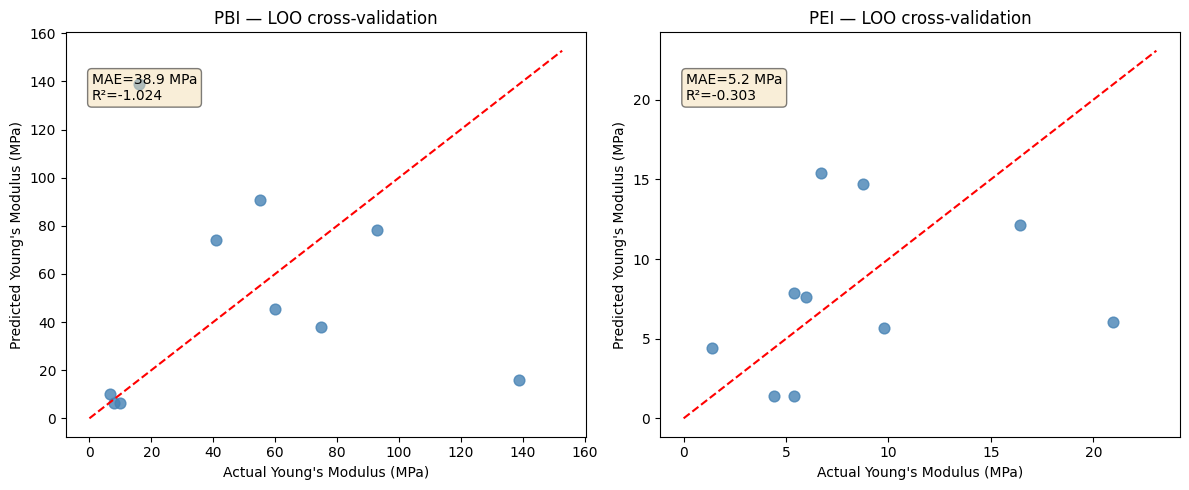

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, polymer in zip(axes, ['PBI', 'PEI']):
    r = results[polymer]
    ax.scatter(r['y_true'], r['y_pred'],
               color='steelblue', s=60, alpha=0.8)
    lim = max(max(r['y_true']), max(r['y_pred'])) * 1.1
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5)
    ax.set_xlabel("Actual Young's Modulus (MPa)")
    ax.set_ylabel("Predicted Young's Modulus (MPa)")
    ax.set_title(f'{polymer} — LOO cross-validation')
    ax.text(0.05, 0.90,
            f"MAE={r['MAE']:.1f} MPa\nR²={r['R2']:.3f}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

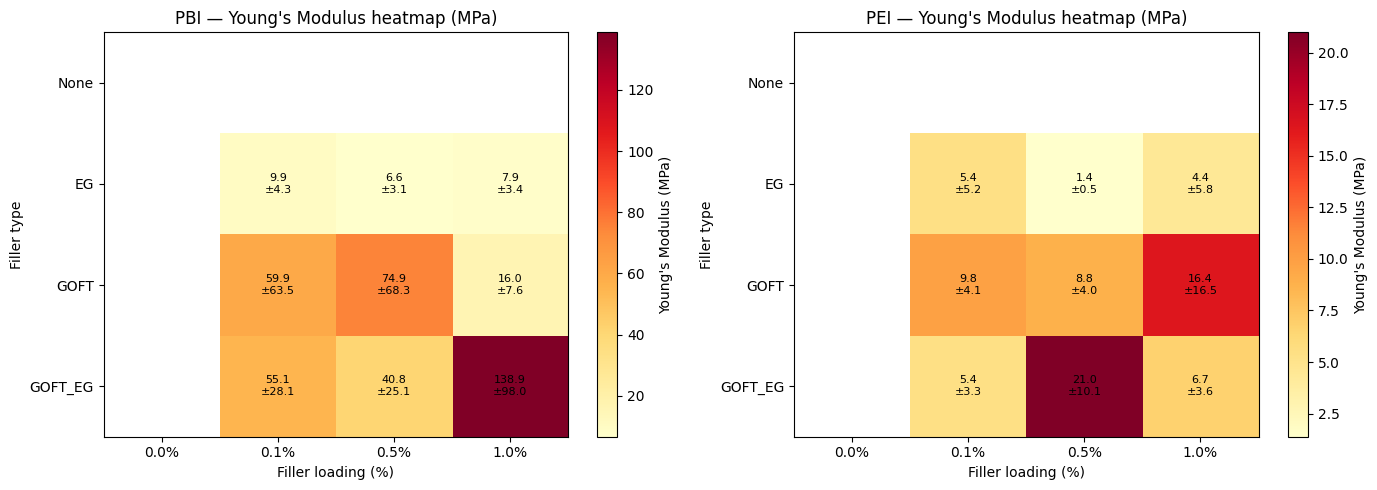

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Pivot data for heatmap
fillers = ['None', 'EG', 'GOFT', 'GOFT_EG']
loadings = [0.0, 0.1, 0.5, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, polymer in zip(axes, ['PBI', 'PEI']):
    subset = df[df['polymer'] == polymer]

    # Build matrix: rows=fillers, cols=loadings
    matrix = np.zeros((len(fillers), len(loadings)))
    annot = np.empty((len(fillers), len(loadings)), dtype=object)

    for i, filler in enumerate(fillers):
        for j, loading in enumerate(loadings):
            # None filler only exists at loading=0
            if filler == 'None' and loading != 0.0:
                matrix[i, j] = np.nan
                annot[i, j] = '-'
                continue
            if filler != 'None' and loading == 0.0:
                matrix[i, j] = np.nan
                annot[i, j] = '-'
                continue
            row = subset[(subset['filler_type'] == filler) &
                         (subset['loading_pct'] == loading)]
            if len(row) > 0:
                val = row['youngs_modulus_MPa'].values[0]
                sd = row['youngs_modulus_sd'].values[0]
                matrix[i, j] = val
                annot[i, j] = f'{val:.1f}\n±{sd:.1f}'
            else:
                matrix[i, j] = np.nan
                annot[i, j] = '-'

    # Mask NaN for colormap
    masked = np.ma.array(matrix, mask=np.isnan(matrix))

    im = ax.imshow(masked, cmap='YlOrRd', aspect='auto')
    plt.colorbar(im, ax=ax, label="Young's Modulus (MPa)")

    # Labels
    ax.set_xticks(range(len(loadings)))
    ax.set_xticklabels([f'{l}%' for l in loadings])
    ax.set_yticks(range(len(fillers)))
    ax.set_yticklabels(fillers)
    ax.set_xlabel('Filler loading (%)')
    ax.set_ylabel('Filler type')
    ax.set_title(f'{polymer} — Young\'s Modulus heatmap (MPa)')

    # Annotate each cell
    for i in range(len(fillers)):
        for j in range(len(loadings)):
            if annot[i, j] != '-':
                ax.text(j, i, annot[i, j],
                        ha='center', va='center',
                        fontsize=8, color='black')

plt.tight_layout()
plt.show()